In [1]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, classification_report

In [2]:
data = pd.read_csv('Heart_Disease_Prediction.csv')
data.head(2)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence


In [3]:
# Mudando variável Heart Disease para binária
data['Heart Disease'].unique()
heart_map = {"Presence": 1, "Absence": 0}
data['Heart Disease'] = data['Heart Disease'].map(heart_map)

In [4]:
# Verificando tipos de dados
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    int64  
dtypes: float64(1), int64(13)
m

In [5]:
# Verificando dados faltantes
data.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

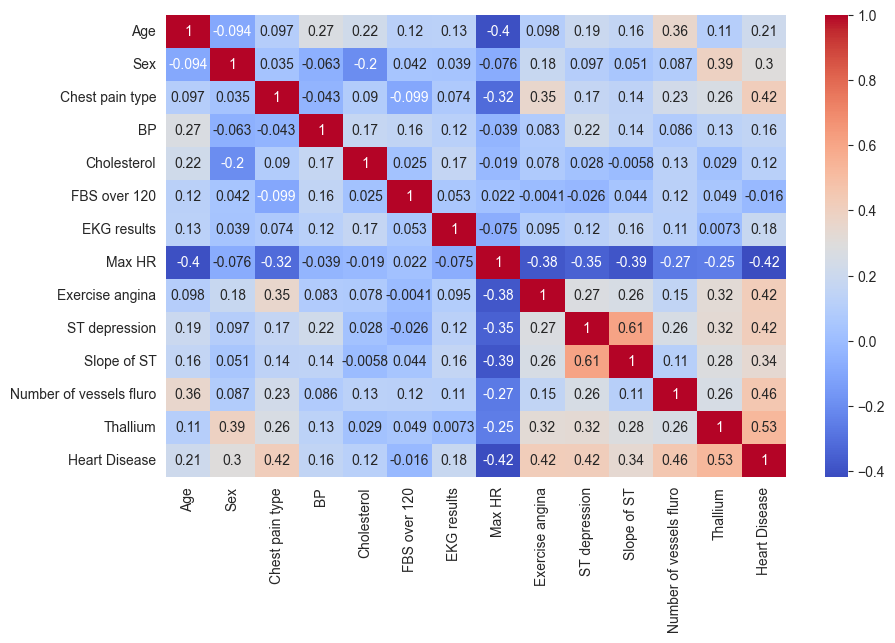

In [6]:
# Gráfico de calor da relação entre variáveis.
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [7]:
# Remoção da variável 'FBS over 120', pois tem uma relação muito baixa com a variável alvo. Não removerei mais variáveis, pois os modelos que utilizados trabalham bem muitas variáveis e todas as variáveis restantes têm uma relação não insignificante com a variável alvo.
data.drop(columns=['FBS over 120'], inplace = True)

In [ ]:
# Analises exploratórias.

In [43]:
media_Thallium = data.groupby('Heart Disease')['Thallium'].mean().reset_index()

fig_Thallium = px.bar(media_Thallium, x='Heart Disease', y='Thallium')
fig_Thallium.show()

# A variável 'Thallium' tem 52% de relação com a variável alvo. No gráfico podemos ver que as pessoas com doença no coração tem o número dessa variável mais alta, 5.83 para quem tem doença no coração contra 3.79 para pessoas sem doença no coração.

In [38]:
media_fluro = data.groupby('Heart Disease')['Number of vessels fluro'].mean().reset_index()

fig_fluro = px.bar(media_fluro, x='Heart Disease', y='Number of vessels fluro')
fig_fluro.show()

# A variável 'Number of vessels fluro' tem 46% de relação com a variável alvo. No gráfico abaixo podemos ver que quem tem doença no coração tem mais vasos fluro do que quem não tem, uma média de 1.15 para pessoas doentes contra 0.29 para quem não tem nenhuma doença no coração.

In [41]:
media_hr = data.groupby('Heart Disease')['ST depression'].mean().reset_index()

fig_hr = px.bar(media_hr, x='Heart Disease', y='ST depression')
fig_hr.show()

# A variável 'ST depression' tem 42% de relação com a variável alvo. No gráfico abaixo podemos ver que quem tem doença no coração tem uma depressão st mais alta, uma média de 1.55 contra 0.62 de quem não tem doença no coração.

In [40]:
data_grouped = data.groupby(['Heart Disease', 'Exercise angina']).size().reset_index(name='count')
total_churn = data_grouped.groupby('Heart Disease')['count'].transform('sum')
data_grouped['percent'] = data_grouped['count'] / total_churn * 100

fig = px.bar(data_grouped, x='Heart Disease', y='percent', color='Exercise angina', barmode='stack')
fig.show()

# A variável 'Exercise angina' tem 42% de relação com a variável alvo. No gráfico a seguir podemos ver que a maioria das pessoas com angina tem uma propensão maior a ter problema de coração. Nessa tabela cerca de 15% das pessoas que não tem problema de coração tem angina, em contrapartida, 55% das pessoas com problema de coração tem angina.

In [8]:
data.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,0.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,0.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,1.000000


In [9]:
# Tratamento de outliers
data.loc[data['BP'] > 170, 'BP'] = 170
data.loc[data['Cholesterol'] > 360, 'Cholesterol'] = 360
data.loc[data['Max HR'] < 88, 'Max HR'] = 88
data.loc[data['ST depression'] > 4, 'ST depression'] = 4

In [10]:
# Verificação de outliers das colunas numéricas
fig = px.box(data, y='ST depression')
fig.show()

In [11]:
# Separação da variável alvo.
x = data.drop('Heart Disease', axis=1)
y = data['Heart Disease']

# Padronização
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Separando em treino e teste
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.25, random_state=66)

# Balanceado variáveis
smote = SMOTE(random_state=50)
x_balanced, y_balanced = smote.fit_resample(x_train, y_train)

In [12]:
# Validação cruzada
folds = 5
cross_validation = KFold(n_splits=folds, shuffle=True, random_state=5)

In [ ]:
# Para utilizar GridSearchCV fui adicionando parâmetros aos poucos até achar a melhor pontuação do cross validation.

In [19]:
# Testando modelo xgboost
xgboost_model = xgb.XGBClassifier(random_state=50)

xgb_default = cross_val_score(xgboost_model, x_balanced, y_balanced, cv=cross_validation)

xgb_grid = {
    'n_estimators': [50],
    'max_depth': [4],
    'learning_rate': [0.2],
    'subsample': [0.7],
    'colsample_bytree': [0.7],
    'gamma': [0],
    'min_child_weight': [4],
    'booster': ['dart'],
    'lambda': [0],
    'alpha': [0],
}

grid_search_xgb = GridSearchCV(xgboost_model, xgb_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_xgb.fit(x_balanced, y_balanced)
best_params_xgb = grid_search_xgb.best_params_
print(f"Melhores parâmetros xgb: {best_params_xgb}")

best_model_xgb = grid_search_xgb.best_estimator_

xgb_best = cross_val_score(best_model_xgb, x_balanced, y_balanced, cv=cross_validation)

print("Pontuações xgb_default: ")
print(xgb_default.mean())
print("Pontuações xgb_best: ")
print(xgb_best.mean())

xgb_predict = best_model_xgb.predict(x_test)
xgb_relatorio = classification_report(y_test, xgb_predict)
print("Relatório de xgb:")
print(xgb_relatorio)

# Calcular a AUC
roc_auc_xgb = roc_auc_score(y_test, xgb_predict)
print("AUC: {:.2f}".format(roc_auc_xgb))

Melhores parâmetros xgb: {'alpha': 0, 'booster': 'dart', 'colsample_bytree': 0.7, 'gamma': 0, 'lambda': 0, 'learning_rate': 0.2, 'max_depth': 4, 'min_child_weight': 4, 'n_estimators': 50, 'subsample': 0.7}
Pontuações xgb_default: 
0.8486702127659574
Pontuações xgb_best: 
0.8616134751773048
Relatório de xgb:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77        31
           1       0.81      0.81      0.81        37

    accuracy                           0.79        68
   macro avg       0.79      0.79      0.79        68
weighted avg       0.79      0.79      0.79        68

AUC: 0.79


In [31]:
# Testando modelo SVM
svm_model = SVC(random_state = 50)

svm_default = cross_val_score(svm_model, x_balanced, y_balanced, cv=cross_validation)

svm_grid = {
'C': [0.9],
'kernel': ['poly'],
'gamma': ['scale'],
'degree': [3],
'max_iter': [-1],
'decision_function_shape': ['ovo']
}


grid_search_svm = GridSearchCV(svm_model, svm_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_svm.fit(x_balanced, y_balanced)
best_params_svm = grid_search_svm.best_params_
print(f"Melhores parâmetros svm: {best_params_svm}")

best_model_svm = grid_search_svm.best_estimator_

svm_best = cross_val_score(best_model_svm, x_balanced, y_balanced, cv=cross_validation)

print("Pontuações svm_default: ")
print(svm_default.mean())
print("Pontuações svm_best: ")
print(svm_best.mean())

svm_predict = best_model_svm.predict(x_test)
svm_relatorio = classification_report(y_test, svm_predict)
print("Relatório de svm:")
print(svm_relatorio)

# Calcular a AUC
roc_auc_svm = roc_auc_score(y_test, svm_predict)
print("AUC: {:.2f}".format(roc_auc_svm))

Melhores parâmetros svm: {'C': 0.9, 'decision_function_shape': 'ovo', 'degree': 3, 'gamma': 'scale', 'kernel': 'poly', 'max_iter': -1}
Pontuações svm_default: 
0.8781914893617021
Pontuações svm_best: 
0.8823581560283686
Relatório de svm:
              precision    recall  f1-score   support

           0       0.79      0.71      0.75        31
           1       0.78      0.84      0.81        37

    accuracy                           0.78        68
   macro avg       0.78      0.77      0.78        68
weighted avg       0.78      0.78      0.78        68

AUC: 0.77


In [36]:
# Testando modelo random forest
rf_model = RandomForestClassifier(random_state=50)

forest_default = cross_val_score(rf_model, x_balanced, y_balanced, cv=cross_validation)

forest_grid = {
    'n_estimators': [100],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
    'criterion': ['gini'],
    'min_weight_fraction_leaf': [0.0],
    'max_leaf_nodes': [None],
    'min_impurity_decrease': [0.1],
}

grid_search_forest = GridSearchCV(rf_model, forest_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search_forest.fit(x_balanced, y_balanced)
best_params_forest = grid_search_forest.best_params_
print(f"Melhores parâmetros forest: {best_params_forest}")

best_model_forest = grid_search_forest.best_estimator_

forest_best = cross_val_score(best_model_forest, x_balanced, y_balanced, cv=cross_validation)

print("Pontuações forest_default: ")
print(forest_default.mean())
print("Pontuações forest_best: ")
print(forest_best.mean())

forest_predict = best_model_forest.predict(x_test)
forest_relatorio = classification_report(y_test, forest_predict)
print("Relatório de forest:")
print(forest_relatorio)

# Calcular a AUC
roc_auc_forest = roc_auc_score(y_test, forest_predict)
print("AUC: {:.2f}".format(roc_auc_forest))

Melhores parâmetros forest: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_impurity_decrease': 0.1, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100}
Pontuações forest_default: 
0.8739361702127659
Pontuações forest_best: 
0.8822695035460993
Relatório de forest:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        31
           1       0.82      0.84      0.83        37

    accuracy                           0.81        68
   macro avg       0.81      0.81      0.81        68
weighted avg       0.81      0.81      0.81        68

AUC: 0.81


In [ ]:
# Após a comparação entre os três modelos, o Random Forest apresentou o melhor desempenho considerando todas as métricas.

# O modelo alcançou um valor de AUC de 0,81 na predição da base de teste e uma média de acurácia de 0,88 no cross-validation, o que indica um desempenho consistente e satisfatório.

# Para aprimorar ainda mais o modelo, uma possível abordagem seria ampliar a base de dados e incluir novas variáveis com maior correlação com a variável alvo.